<a href="https://colab.research.google.com/github/MiguelAngeloTr/Aprendizaje_Automatico/blob/main/SEMANA_5/TAREA3/3_variables_Clasificaci%C3%B3n_usando_perceptron_Adaline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TAREA 3 BILLETES CON 3 CARACTERISTICAS

#Estudiante : Miguel Angel Jimenez Trochez


#EDA

In [2]:

# ------------------------------------------------------------
# 1. Importación de librerías
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid', palette='deep', font_scale=1.1)

# ------------------------------------------------------------
# 2. Carga del dataset
# ------------------------------------------------------------
url = "https://raw.githubusercontent.com/MiguelAngeloTr/Aprendizaje_Automatico/refs/heads/main/SEMANA_5/TAREA3/data_billetes.csv"
billetes = pd.read_csv(url)

print("Dataset cargado correctamente.")
print(f"Filas: {billetes.shape[0]}  |  Columnas: {billetes.shape[1]}")
billetes.head()




Dataset cargado correctamente.
Filas: 1372  |  Columnas: 5


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [3]:


# ------------------------------------------------------------
# 3. Información general del dataset
# ------------------------------------------------------------
print("\nInformación general del DataFrame:")
billetes.info()

print("\nResumen estadístico de las variables numéricas:")
display(billetes.describe().T)

# ------------------------------------------------------------
# 4. Revisión de valores nulos y duplicados
# ------------------------------------------------------------
print("\nValores nulos por columna:")
print(billetes.isnull().sum())

print("\nRegistros duplicados:")
print(billetes.duplicated().sum())
print(billetes[billetes.duplicated()])



Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB

Resumen estadístico de las variables numéricas:


,count,mean,std,min,25%,50%,75%,max
variance,1372.0,0.433735,2.842763,-7.0421,-1.773000,0.49618,2.821475,6.8248
skewness,1372.0,1.922353,5.869047,-13.7731,-1.708200,2.31965,6.814625,12.9516
curtosis,1372.0,1.397627,4.310030,-5.2861,-1.574975,0.61663,3.179250,17.9274
entropy,1372.0,-1.191657,2.101013,-8.5482,-2.413450,-0.58665,0.394810,2.4495
class,1372.0,0.444606,0.497103,0.0000,0.000000,0.00000,1.000000,1.0000



Valores nulos por columna:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Registros duplicados:
24
     variance  skewness  curtosis  entropy  class
47    -0.7869    9.5663   -3.7867  -7.5034      0
139   -0.2062    9.2207   -3.7044  -6.8103      0
190    0.9297   -3.7971    4.6429  -0.2957      0
195   -1.8584    7.8860   -1.6643  -1.8384      0
226    0.5706   -0.0248    1.2421  -0.5621      0
268    0.9297   -3.7971    4.6429  -0.2957      0
284   -1.3000   10.2678   -2.9530  -5.8638      0
300    0.3292   -4.4552    4.5718  -0.9888      0
315    0.3292   -4.4552    4.5718  -0.9888      0
320    0.5195   -3.2633    3.0895  -0.9849      0
345   -1.8584    7.8860   -1.6643  -1.8384      0
351    0.5195   -3.2633    3.0895  -0.9849      0
352    0.3292   -4.4552    4.5718  -0.9888      0
404    0.3798    0.7098    0.7572  -0.4444      0
427   -1.3000   10.2678   -2.9530  -5.8638      0
436    0.3798    0.7098    0.7572  -0.4444      0
476    0.3798


Registros duplicados:
0
(1348, 5)


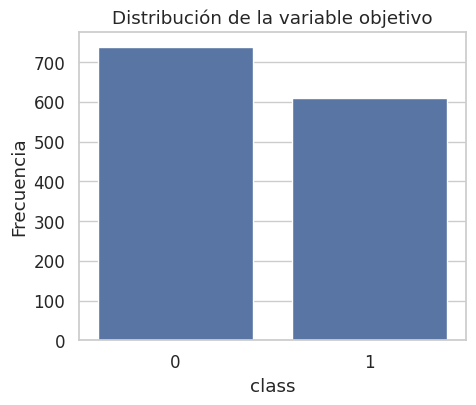

In [4]:
#Eliminar duplicados
billetes = billetes.drop_duplicates()
print("\nRegistros duplicados:")
print(billetes.duplicated().sum())

print(billetes.shape)
# ------------------------------------------------------------
# 5. Distribución de la variable objetivo
# ------------------------------------------------------------
# Se asume que la última columna corresponde a la variable objetivo
target_col = 'target_class' if 'target_class' in billetes.columns else billetes.columns[-1]

plt.figure(figsize=(5,4))
sns.countplot(data=billetes, x=target_col)
plt.title('Distribución de la variable objetivo')
plt.xlabel(target_col)
plt.ylabel('Frecuencia')
plt.show()


Se decide que el desbalanceo es leve y no requiere tecnicas de balanceo

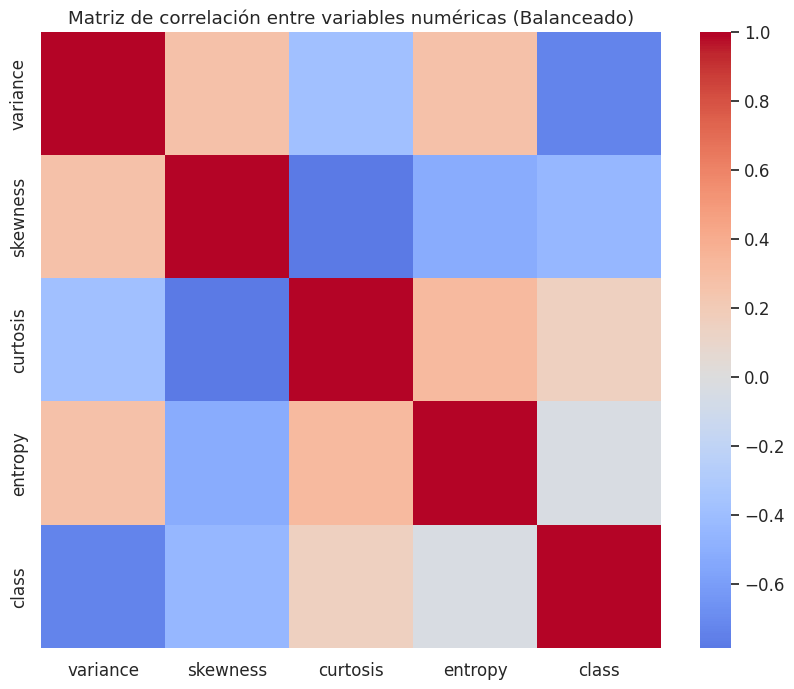

In [5]:

# ------------------------------------------------------------
# 6. Matriz de correlación
# ------------------------------------------------------------
plt.figure(figsize=(10,8))
corr = billetes.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de correlación entre variables numéricas (Balanceado)')
plt.show()


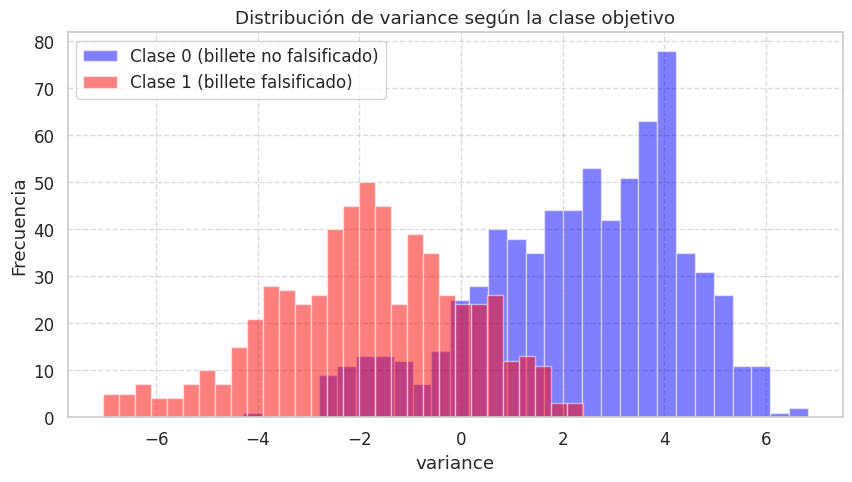

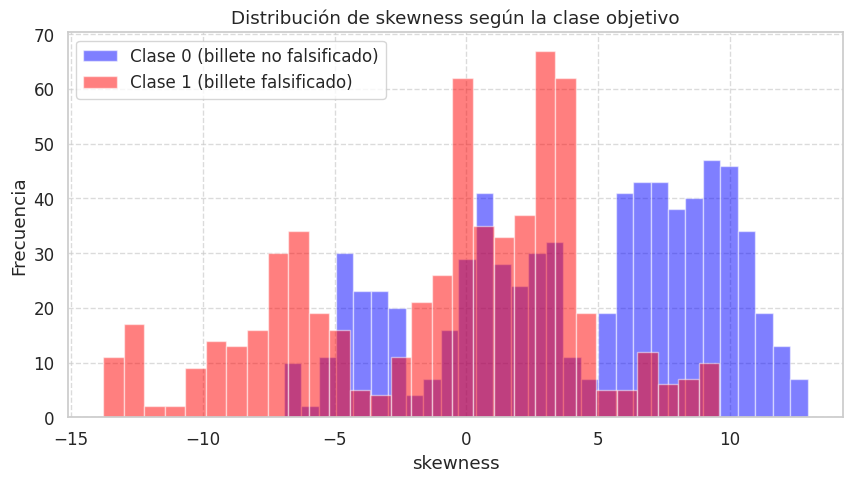

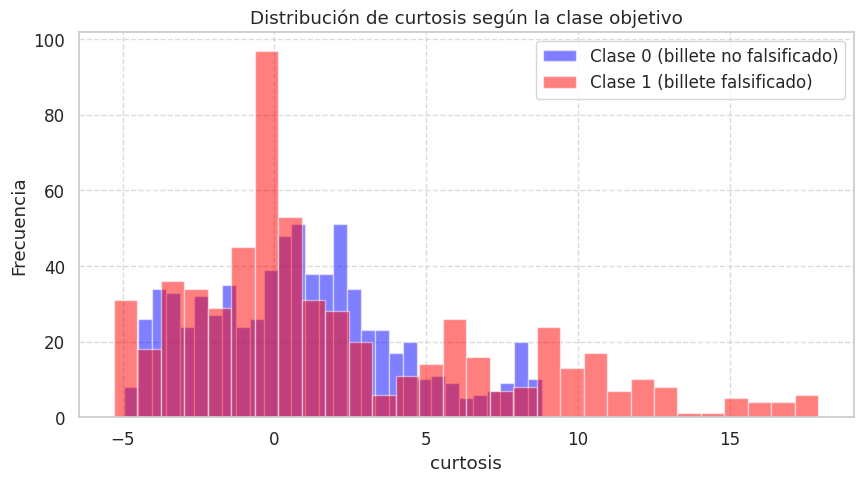

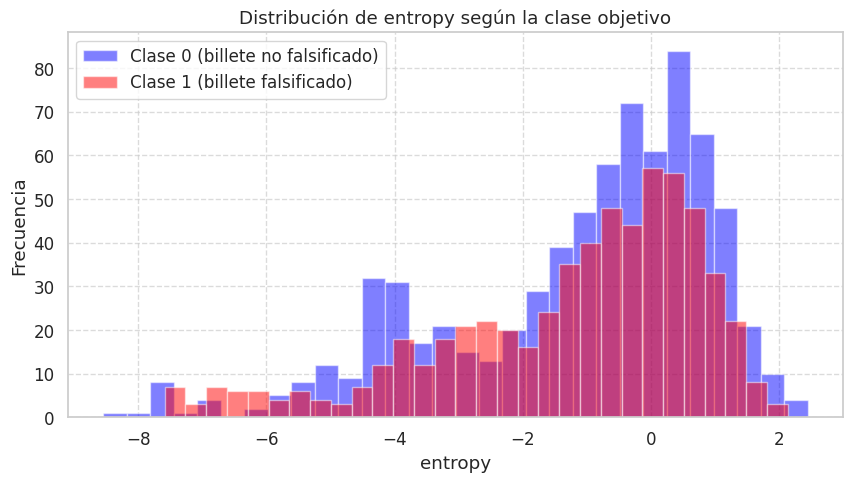

In [6]:
# -----------------------------------------
# COMPARACIÓN DE DISTRIBUCIONES POR CLASE
# -------------------------------------------

import matplotlib.pyplot as plt

# Identificar variable objetivo
target_col = 'target_class' if 'target_class' in billetes.columns else billetes.columns[-1]

# Definir características numéricas (todas menos la target)
features = [col for col in billetes.columns if col != target_col]

# Crear histogramas comparativos por clase
for feature in features:
    plt.figure(figsize=(10, 5))

    billetes[billetes[target_col] == 0][feature].plot(
        kind='hist', alpha=0.5, color='blue', bins=30, label='Clase 0 (billete no falsificado)')

    billetes[billetes[target_col] == 1][feature].plot(
        kind='hist', alpha=0.5, color='red', bins=30, label='Clase 1 (billete falsificado)')

    plt.title(f'Distribución de {feature} según la clase objetivo')
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

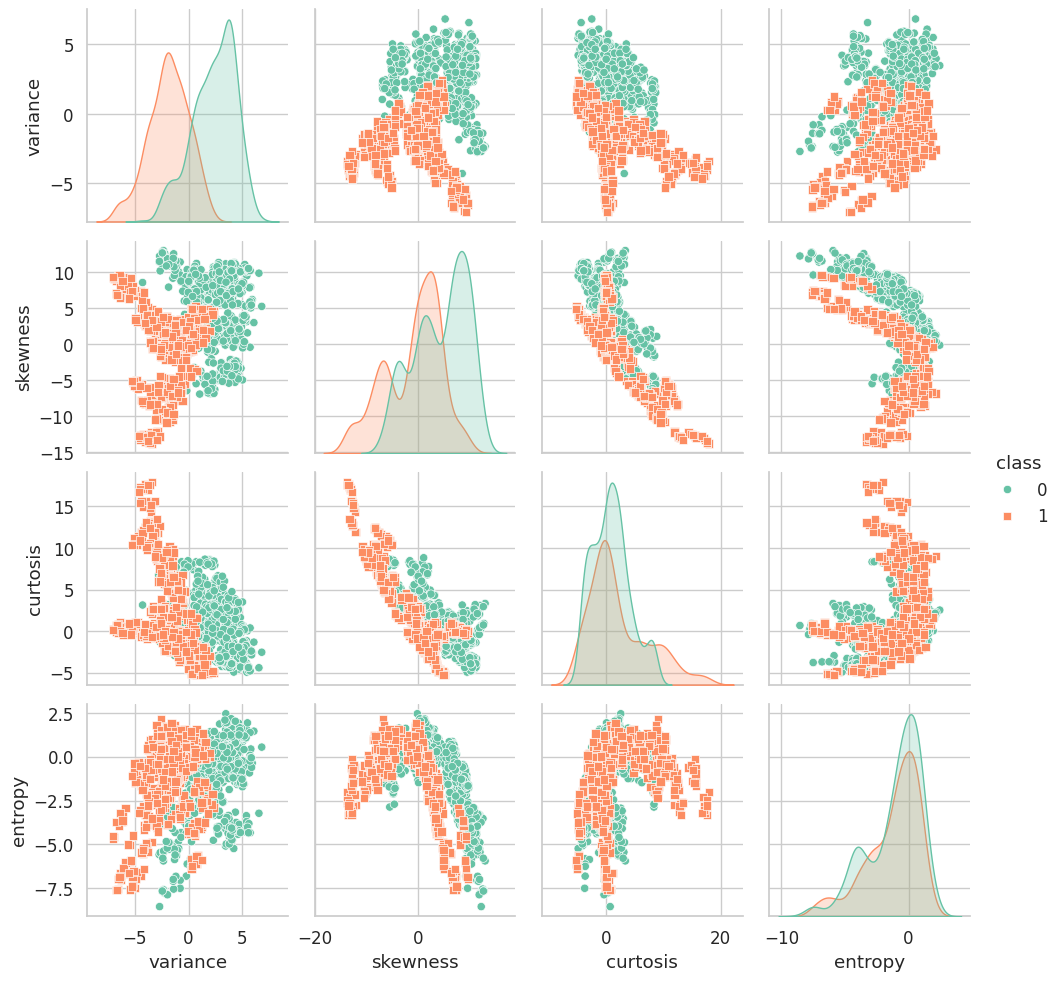

In [7]:

import seaborn as sns
sns.pairplot(billetes, hue="class", markers=["o", "s"], palette="Set2")

Las variables con una mejor separabilidad visual son variance y curtosis ya que se logra ver que los puntos azules y naranjas diferenciados y se nota una ligera frontera entre ellos

2. En función del ítem 1, seleccione las TRES características y genere tanto la matriz de características
X como el vector de targets y

In [25]:

X = billetes[['variance', 'curtosis', 'skewness']]
y = billetes['class']

print(X)
print(y)

      variance  curtosis  skewness
0      3.62160   -2.8073   8.66610
1      4.54590   -2.4586   8.16740
2      3.86600    1.9242  -2.63830
3      3.45660   -4.0112   9.52280
4      0.32924    4.5718  -4.45520
...        ...       ...       ...
1367   0.40614   -1.4501   1.34920
1368  -1.38870    6.4774  -4.87730
1369  -3.75030   17.5932 -13.45860
1370  -3.56370   12.3930  -8.38270
1371  -2.54190    2.6842  -0.65804

[1348 rows x 3 columns]
0       0
1       0
2       0
3       0
4       0
       ..
1367    1
1368    1
1369    1
1370    1
1371    1
Name: class, Length: 1348, dtype: int64


3. Cree un universo de entrenamiento (x_train, y_train) y uno de prueba (x_test, y_test). Asegúrese de
que el porcentaje de datos del universo de prueba sea el 20%.

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y)


In [28]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


(1078, 3) (270, 3)
(1078,) (270,)


4. Realice un gráfico que permita ver la variabilidad de las tres características (gráfico de dispersión)
para las clases presentes solo de (x_train, y_train)

Se presenta la distribucion de los datos para verificar básicamente como estan distribuidos



In [36]:
# ===============================================================
# Gráfico 3D: varianza, curtosis y skewness (datos de entrenamiento)
# ===============================================================
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # para graficar en 3D

# 1. Separar las clases
X_no_falsificado = X_train[y_train == 0]
X_falsificado = X_train[y_train == 1]



# 4. Etiquetas y título
import plotly.express as px
fig = px.scatter_3d(X_train, x='variance', y='curtosis', z='skewness', color=y_train.map({0:'No falsificado', 1:'Falsificado'}))
fig.show()

ax.legend()

# 5. Mostrar gráfico
plt.tight_layout()
plt.show()



/tmp/ipython-input-1826837772.py:18: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



<Figure size 640x480 with 0 Axes>

Los billetes falsificados (azules) tienden a concentrarse hacia la izquierda (valores de varianza más negativos y curtosis más alta).

Los billetes no falsificados (rojos) se agrupan hacia la derecha, con varianza positiva y curtosis más baja o incluso negativa.

#CLASE TIPO PERCEPTRON

5. Utilice sus datos del universo de entrenamiento para ajustar un modelo tipo Perceptron.


In [13]:

class Perceptron(object):
    """Clasificador Perceptron.

    Parámetros
    ------------
    |eta : float
      Tasa de aprendizaje (entre 0.0 y 1.0)
    |n_iter : int
      Número de iteraciones sobre el dataset.
    |random_state : int
      Semilla del generador de números aleatorios para la inicialización del bias y pesos aleatorios.
    |Rw: int
      (Rw; Random weights), Tipo de forma en la cual se generaran el bias y pesos aleatorios.

      Si se usa por defecto 0:

      ** Es un vector que contiene pequeños números aleatorios extraídos de una distribución normal
      con distribución normal y desviación estandar 0.01

      Si se usa 1:

      ** Valores aleatorios en el rango de -25 a +25, asegurándose de que ninguno sea igual a cero
      excepto el primer valor, que es el bias. Los valores que se hubieran generado como cero se reemplazarán
      por valores muy pequeños (0.0001) multiplicados por un factor aleatorio de -1 o 1.
    |Af: String
      (Af;Activation Function), Tipo de función de aprendizaje: step_function o bipolar_step_function.


    Atributos
    -----------
    |w_ : Arreglo 1D
      Pesos antes del entrenamiento (Iniciales).
    |errors_ : list
      Número de clasificaciones erróneas (actualizaciones) en cada época.
    |w_historical: list
      Almacena todos los valores de bias y pesos obtenidos en cada época:

      [Pesos iniciales, Pesos_iter1, Pesos_inter2,....Pesos_n_iter]

      La dimensión de la lista es: 1 x (1 + n_iter)

    """
    #FUNCIÓN PARA INICIALIZAR MI PERCEPTRON
    def __init__(self, eta=0.01, n_iter=50, Af='step_function', Rw=0 , random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
        self.Rw = Rw
        self.Af = Af


    #FUNCIÓN PARA ENTRENAR MI CONJUNTO DE DATOS USANDO MI PERCEPTRON
    def fit(self, X, y):
        """Datos de entrenamiento para ajustar.

        Parameters
        ----------
        X : {Tipo matriz}, Dimensión = [n_muestras, n_características]
          Training vectors, donde n_muestras es el número de muestras y
          n_características es el número de características.
        y : Tipo vector fila, shape = [n_samples]
          Target values.

        Retorna
        -------
        self : objeto

        """
        rgen = np.random.RandomState(self.random_state)

        if(self.Rw == 0):
          self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        elif(self.Rw == 1):
          lower_bound = -25
          upper_bound = 25
          self.w_ = rgen.uniform(low=lower_bound, high=upper_bound, size=1 + X.shape[1])
          # Asegurar que ningún valor sea igual a cero, excepto el primer valor
          self.w_[1:] = np.where(self.w_[1:] == 0, np.random.choice([-1, 1], size=self.w_[1:].shape) * 0.0001, self.w_[1:])
        else:
          print("Error, solo se puede usar 0 o 1.")

        """
        Genera el vector de pesos de manera aleatoria [Un peso W1 hasta ...Wn]
        Donde n, corresponde al número de caractarísticas de que presente las
        muestras del dataset + 1 elemento adicional que es el BIAS.
        """


        """
        Incializa el vector de errores vacio, dado que lo llenará en función de
        cada iteración.
        """

        self.errors_ = []
        self.w_historical = [self.w_.copy()]  # Agrega los pesos iniciales a la lista

        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_[1:] += update * xi
                self.w_[0] += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
            self.w_historical.append(self.w_.copy())  # Guarda una copia de los pesos actuales en cada iteración
        return self

    def net_input(self, X):
        """Calcular la entrada NETA:"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        Activation_function = self.Af

        """Devolver el valor de predicción final (pasando por la función de activación)"""

        if(Activation_function =='step_function'):
          return np.where(self.net_input(X) >= 0.0, 1, 0)
        elif(Activation_function =='bipolar_step_function'):
          return np.where(self.net_input(X) >= 0.0, 1, -1)
        else:
          print("Error, solo puede ser 'step_function' o 'bipolar_step_function'")





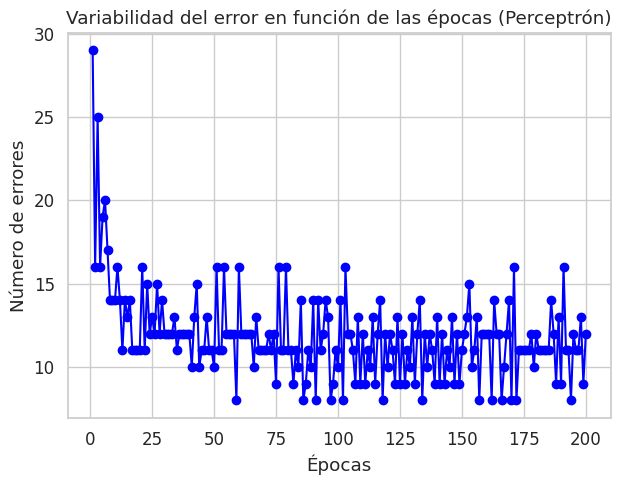

In [37]:
# 5.1  Variabilidad del error en función de las épocas de entrenamiento

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Normalizar los datos
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

# 2. Usar directamente las etiquetas originales (0 y 1)
y_train_bin = y_train.values
y_test_bin = y_test.values

# 3. Crear y entrenar el perceptrón con step_function
ppn = Perceptron(eta=0.01, n_iter=200, Af='step_function', Rw=0)
ppn.fit(X_train_std, y_train_bin)

# 4. Graficar la variabilidad del error
plt.figure(figsize=(7,5))
plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o', color='blue')
plt.xlabel('Épocas')
plt.ylabel('Número de errores')
plt.title('Variabilidad del error en función de las épocas (Perceptrón)')
plt.grid(True)
plt.show()


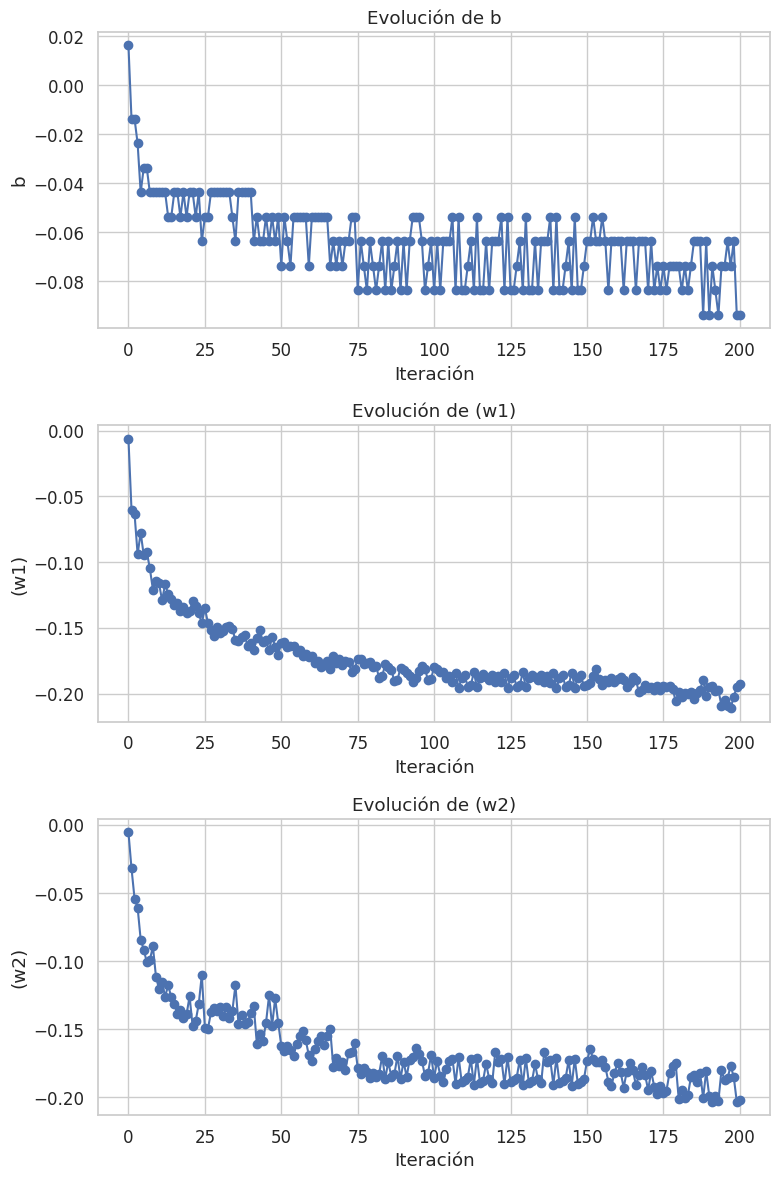

In [40]:
#-- 5.2 Debe de presentar un gráfico de variabilidad de los hiperparámetros del Perceptron (𝑤1,𝑤2 𝑦 𝑏)
#-- en función de las épocas de entrenamiento.



import matplotlib.pyplot as plt

# Lista de etiquetas para los gráficos
labels = ['b', '(w1)', '(w2)']

# Crear tres subgráficos
fig, axs = plt.subplots(3, 1, figsize=(8, 12))

# Iterar sobre cada etiqueta y crear un gráfico correspondiente
for i, label in enumerate(labels):
    # Extraer la serie temporal para la etiqueta actual
    series = [weights[i] for weights in ppn.w_historical]

    # Graficar la serie temporal
    axs[i].plot(range(len(ppn.w_historical)), series, marker='o')
    axs[i].set_title(f'Evolución de {label}')
    axs[i].set_xlabel('Iteración')
    axs[i].set_ylabel(label)



# Ajustar espaciado entre subgráficos
plt.tight_layout()

# Mostrar los gráficos
plt.show()










In [39]:
print(ppn.w_historical[0])

[ 0.01624345 -0.00611756 -0.00528172 -0.01072969]


In [47]:
#-- 5.3. En una nueva figura, debe de presentar la recta de separación inicial (cuando los
#-- hiperparámetros aleatorios arrancan por primera vez). Esto realizarlo sobre el gráfico del ítem
#-- 4. Tenga en cuenta, que lo que se trata de mostrar es que justamente la primera vez (con los
#-- pesos aleatorios) la separación para las clases es deficiente.

import numpy as np
import plotly.graph_objects as go

# Usar las tres variables estandarizadas
X3 = X_train_std[:, :3]  # variance, skewness, curtosis
y3 = y_train.values

# Obtener los pesos iniciales del Perceptrón (antes del entrenamiento)
w_init = ppn.w_historical[0]  # pesos aleatorios iniciales
b = w_init[0]
w1, w2, w3 = w_init[1], w_init[2], w_init[3]

# Generar malla para el plano
x_min, x_max = X3[:, 0].min(), X3[:, 0].max()
y_min, y_max = X3[:, 1].min(), X3[:, 1].max()
x_plane, y_plane = np.meshgrid(np.linspace(x_min, x_max, 20),
                               np.linspace(y_min, y_max, 20))
z_plane = (-w1 * x_plane - w2 * y_plane - b) / w3

# Crear figura 3D
fig = go.Figure()

# Añadir los puntos por clase
for label, color, name in zip([0, 1], ['red', 'blue'], ['No falsificado', 'Falsificado']):
    fig.add_trace(go.Scatter3d(
        x=X3[y3 == label, 0],
        y=X3[y3 == label, 1],
        z=X3[y3 == label, 2],
        mode='markers',
        marker=dict(size=5, color=color, opacity=0.8),
        name=name
    ))

# Añadir el plano de separación inicial
fig.add_trace(go.Surface(
    x=x_plane,
    y=y_plane,
    z=z_plane,
    opacity=0.5,
    colorscale='Greens',
    showscale=False,
    name='Plano inicial (pesos aleatorios)'
))

# Configurar los ejes y el diseño
fig.update_layout(
    scene=dict(
        xaxis=dict(title='Varianza (escalada)'),
        yaxis=dict(title='Asimetría (Skewness, escalada)'),
        zaxis=dict(title='Curtosis (escalada)'),
        xaxis_showspikes=False,
        yaxis_showspikes=False,
        zaxis_showspikes=False
    ),
    title='Frontera de separación inicial – Pesos aleatorios (3 variables)',
    width=900,
    height=700,
    showlegend=True
)

# Mostrar figura interactiva
fig.show()




In [48]:
#-- 5.4. En una nueva figura, debe de presentar la recta de separación final (los hiperparámetros
#-- aleatorios finales, cuando su Perceptron ha terminado de entrenar). Esto realizarlo sobre el
#-- gráfico del ítem 4. Tenga en cuenta, que lo que se trata de mostrar es el resultado final obtenido
#-- cuando el modelo ha terminado de entrenar “convergencia”.

# EPOCA POR EPOCA -------------- SALTAR SI SE QUIERE VISUALIZAR EL FINAL #

import numpy as np
import plotly.graph_objects as go

# Usar las tres variables estandarizadas
X3 = X_train_std[:, :3]  # variance, skewness, curtosis
y3 = y_train.values

# Obtener los pesos finales del modelo entrenado
w_final = ppn.w_historical[-1]  # últimos pesos después del entrenamiento
b = w_final[0]
w1, w2, w3 = w_final[1], w_final[2], w_final[3]

# Crear la malla para el plano de separación
x_min, x_max = X3[:, 0].min(), X3[:, 0].max()
y_min, y_max = X3[:, 1].min(), X3[:, 1].max()
x_plane, y_plane = np.meshgrid(np.linspace(x_min, x_max, 20),
                               np.linspace(y_min, y_max, 20))
z_plane = (-w1 * x_plane - w2 * y_plane - b) / w3

# Crear figura 3D interactiva
fig = go.Figure()

# Añadir los puntos por clase (entrenamiento)
for label, color, name in zip([0, 1], ['red', 'blue'], ['No falsificado', 'Falsificado']):
    fig.add_trace(go.Scatter3d(
        x=X3[y3 == label, 0],
        y=X3[y3 == label, 1],
        z=X3[y3 == label, 2],
        mode='markers',
        marker=dict(size=5, color=color, opacity=0.8),
        name=name
    ))

# Añadir el plano final (frontera aprendida)
fig.add_trace(go.Surface(
    x=x_plane,
    y=y_plane,
    z=z_plane,
    opacity=0.5,
    colorscale='Viridis',
    showscale=False,
    name='Plano final (modelo entrenado)'
))

# Configurar ejes y diseño
fig.update_layout(
    scene=dict(
        xaxis=dict(title='Varianza (escalada)'),
        yaxis=dict(title='Asimetría (Skewness, escalada)'),
        zaxis=dict(title='Curtosis (escalada)'),
        xaxis_showspikes=False,
        yaxis_showspikes=False,
        zaxis_showspikes=False
    ),
    title='Frontera de separación final – Modelo entrenado (3 variables)',
    width=900,
    height=700,
    showlegend=True
)

# Mostrar figura interactiva
fig.show()


MATRIZ DE CONFUSION

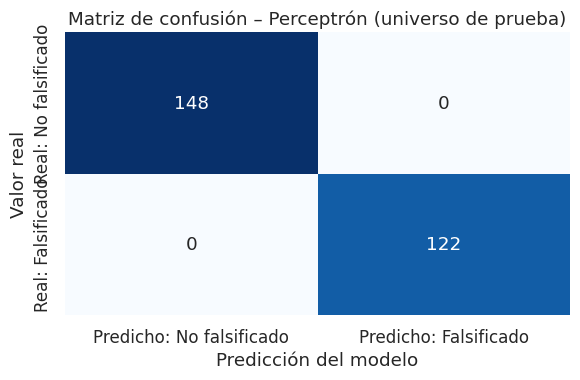

In [49]:
#-- 5.5. Con el modelo entrenado, evaluar con el universo de entrenamiento el Perceptron y desplegar
#-- los resultados mediante una matriz de confusión. ¿Indicar brevemente que puede observar?



from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generar las predicciones del modelo
y_pred_ppn = ppn.predict(X_test_std)

# 2. Calcular la matriz de confusión
cm_ppn = confusion_matrix(y_test, y_pred_ppn)

# 3. Visualizar
plt.figure(figsize=(6,4))
sns.heatmap(cm_ppn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicho: No falsificado', 'Predicho: Falsificado'],
            yticklabels=['Real: No falsificado', 'Real: Falsificado'])
plt.title('Matriz de confusión – Perceptrón (universo de prueba)')
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()



Metricas matriz de confusion

In [50]:
#-- Calcular todas las métricas explicadas en el aula de clase que se pueden obtener a partir de
#-- los resultados obtenidos en el ítem 5.5.

class metricas_matriz_confusion(object):

  #
    def __init__(self, cm):
        self.TP = cm[1][1]
        self.FP = cm[0][1]
        self.FN = cm[1][0]
        self.TN = cm[0][0]

        self.accuracy = (self.TP+self.TN)/(self.TP+self.FP+self.FN+self.TN)
        self.error_rate = (self.FP+self.FN)/(self.TP+self.FP+self.FN+self.TN)
        self.precision = (self.TP)/(self.TP+self.FP)
        self.recall = (self.TP)/(self.TP+self.FN)
        self.especificity = (self.TN)/(self.TN+self.FP)


#Calcular las metricas de la matriz de confusion
metrics_ppn_1 =metricas_matriz_confusion(cm_ppn)

print("El valor de exactitud (accuracy) es: " + str(metrics_ppn_1.accuracy))
print("El valor de tasa de error (error_rate) es: " + str(metrics_ppn_1.error_rate))
print("El valor de precisión (precision) es: " + str(metrics_ppn_1.precision))
print("El valor de recall (sensibilidad / sensitivity / true positive rate) es: " + str(metrics_ppn_1.recall))
print("El valor de especificidad (especificity) es: " + str(metrics_ppn_1.especificity))

El valor de exactitud (accuracy) es: 1.0
El valor de tasa de error (error_rate) es: 0.0
El valor de precisión (precision) es: 1.0
El valor de recall (sensibilidad / sensitivity / true positive rate) es: 1.0
El valor de especificidad (especificity) es: 1.0



Resultados:


El modelo de perceptrón logro una clasificación perfecta en el conjunto de prueba. Con una exactitud del 100 %. No se registraron falsos positivos ni falsos negativos, lo que evidencia una separación lineal completa entre las clases “falsificado” y “no falsificado”.Este resultado confirma que las variables varianza, asimetría (skewness) y curtosis son suficientes para discriminar linealmente los billetes en el espacio de características utilizado.



#ADALINE


In [22]:

#----------------------------------------Punto 6--------------------------------------------------
#Utilice sus datos del universo de entrenamiento para ajustar un modelo tipo Adaline. Ojo: tenga
#presente que puede realizar el intento con los datos sin normalizar y validar el desempeño de la
#red, pero lo más recomendado para un modelo Adaline es realizar el proceso de normalización
#mediante la estandarización (media igual a 0 y varianza igual a 1).
#-------------------------------------------------------------------------------------------------

class AdalineGD(object):
    """ADAptive LInear NEuron classifier.

    Parámetros
    ------------
    |eta : float
      Tasa de aprendizaje (entre 0.0 y 1.0)
    |n_iter : int
      Número de iteraciones sobre el dataset.
    |random_state : int
      Semilla del generador de números aleatorios para la inicialización del bias y pesos aleatorios.


    Atributos
    -----------
    |w_ : Arreglo 1D
      Pesos antes del entrenamiento (Iniciales).
    |cost_  : list
      Valro de la función de costo de suma de cuadrados en cada época.


    """
    #FUNCIÓN PARA INICIALIZAR MI ADALINE
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """ Datos de entrenamiento para ajustar.

          Parameters
        ----------
        X : {Tipo matriz}, Dimensión = [n_muestras, n_características]
          Training vectors, donde n_muestras es el número de muestras y
          n_características es el número de características.
        y : Tipo vector fila, shape = [n_samples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)


        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.cost_ = []

        for i in range(self.n_iter):

            #Se calcula la NETA para todos los valores de entrada
            net_input = self.net_input(X)

            #Observe por favor que a continuación se llama a la función de activación
            #Pero en realidad no tiene efecto, se podría colocar directamente:
            #output = self.net_input(X)
            #Pero el propósito es dejar dispuesto el código para usar la función de activación en otros casos.
            output = self.activation(net_input)

            errors = (y - output)

            self.w_[1:] += self.eta * X.T.dot(errors)

            self.w_[0] += self.eta * errors.sum()

            cost = (errors**2).sum() / 2.0
            self.cost_.append(cost)
        return self

    def net_input(self, X):
        """Calcula el valor neto (Z)"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, X):
        """Función de activación lineal"""
        return X

    def predict(self, X):
        """Retonar el valor de clase perteneciente"""
        return np.where(self.activation(self.net_input(X)) >= 0.0, 1, -1)


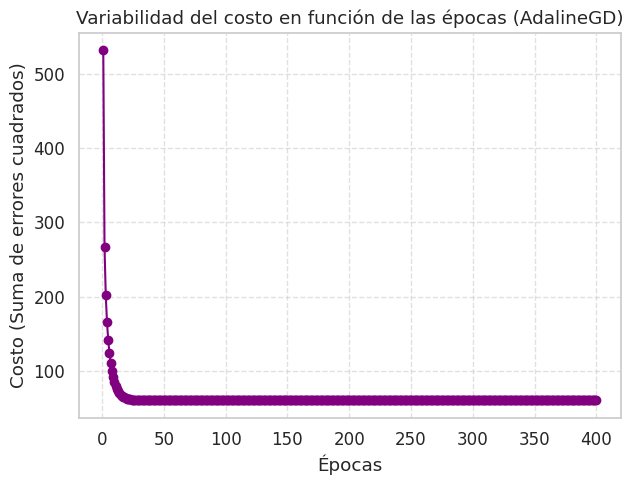

In [51]:
# 6.1  Variabilidad del costo en función de las épocas de entrenamiento (Adaline)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Normalizar los datos (recomendado para Adaline)
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

# 2. Convertir etiquetas a bipolar (-1, 1)
y_train_bipolar = np.where(y_train == 0, -1, 1)
y_test_bipolar = np.where(y_test == 0, -1, 1)

# 3. Crear y entrenar el modelo Adaline
ada = AdalineGD(eta=0.0005, n_iter=400)
ada.fit(X_train_std, y_train_bipolar)

# 4. Graficar la variabilidad del costo
plt.figure(figsize=(7,5))
plt.plot(range(1, len(ada.cost_) + 1), ada.cost_, marker='o', color='purple')
plt.xlabel('Épocas')
plt.ylabel('Costo (Suma de errores cuadrados)')
plt.title('Variabilidad del costo en función de las épocas (AdalineGD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [53]:
# --------------------------------------------------------------
# Gráfico 3D interactivo de la frontera de decisión (billetes)
# --------------------------------------------------------------
import plotly.graph_objects as go
import numpy as np

# Seleccionar tres características para el plano 3D
X3 = X_train_std[:, :3]  # Usaremos las tres primeras: variance, skewness, curtosis
y3 = y_train.values

# Obtener pesos finales del modelo (por ejemplo Adaline o Perceptrón entrenado)
w_final = ada.w_  # o ppn.w_ si deseas graficar el Perceptrón
b = w_final[0]
w1, w2, w3 = w_final[1], w_final[2], w_final[3]

# Crear una malla de puntos para el plano
x_plane = np.linspace(X3[:, 0].min(), X3[:, 0].max(), 20)
y_plane = np.linspace(X3[:, 1].min(), X3[:, 1].max(), 20)
x_plane, y_plane = np.meshgrid(x_plane, y_plane)

# Calcular los valores z del plano (frontera de decisión)
z_plane = (-w1 * x_plane - w2 * y_plane - b) / w3

# Crear figura 3D
fig = go.Figure()

# Añadir puntos de cada clase (entrenamiento)
for label, color, name in zip([0, 1], ['red', 'blue'], ['No falsificado', 'Falsificado']):
    fig.add_trace(go.Scatter3d(
        x=X3[y3 == label, 0],
        y=X3[y3 == label, 1],
        z=X3[y3 == label, 2],
        mode='markers',
        marker=dict(size=5, color=color, opacity=0.8),
        name=name
    ))

# Añadir el plano de separación
fig.add_trace(go.Surface(
    x=x_plane,
    y=y_plane,
    z=z_plane,
    opacity=0.5,
    colorscale='Greens',
    showscale=False,
    name='Frontera de decisión'
))

# Etiquetas de los ejes y configuración general
fig.update_layout(
    scene=dict(
        xaxis=dict(title='Varianza (escalada)'),
        yaxis=dict(title='Asimetría (Skewness, escalada)'),
        zaxis=dict(title='Curtosis (escalada)')
    ),
    title='Frontera de decisión 3D – Modelo Adaline ',
    showlegend=True,
    width=900,
    height=700
)

# Mostrar figura interactiva
fig.show()


In [54]:
# Predicción con el modelo Adaline ya entrenado
y_pred_ada = ada.predict(X_test_std)


Matriz de confusion

[[146   2]
 [  0 122]]


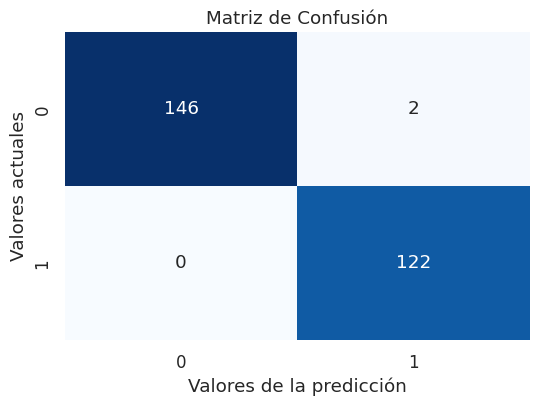

In [55]:
# Calcula la matriz de confusión
cm_ada_1 = confusion_matrix(y_test_bipolar, y_pred_ada)

print(cm_ada_1)

# Graficar la matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(cm_ada_1, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.xlabel('Valores de la predicción')
plt.ylabel('Valores actuales')
plt.title('Matriz de Confusión')
plt.show()

In [56]:
metrics_ada_1 =metricas_matriz_confusion(cm_ada_1)

print("El valor de exactitud (accuracy) es: " + str(metrics_ada_1.accuracy))
print("El valor de tasa de error (error_rate) es: " + str(metrics_ada_1.error_rate))
print("El valor de precisión (precision) es: " + str(metrics_ada_1.precision))
print("El valor de recall (sensibilidad / sensitivity / true positive rate) es: " + str(metrics_ada_1.recall))
print("El valor de especificidad (especificity) es: " + str(metrics_ada_1.especificity))

El valor de exactitud (accuracy) es: 0.9925925925925926
El valor de tasa de error (error_rate) es: 0.007407407407407408
El valor de precisión (precision) es: 0.9838709677419355
El valor de recall (sensibilidad / sensitivity / true positive rate) es: 1.0
El valor de especificidad (especificity) es: 0.9864864864864865


Resultados:

El modelo Adaline, entrenado con las variables varianza, asimetría (skewness) y curtosis, alcanzó una exactitud del 99.26 % en el conjunto de prueba, con una precisión del 98.39 % y una sensibilidad del 100 %. Esto indica que el modelo logró identificar correctamente todos los billetes falsificados, cometiendo muy pocos errores al clasificar los auténticos.

En síntesis, ambos modelos evidencian que las tres variables seleccionadas permiten una separación lineal casi perfecta del conjunto de datos, confirmando su alto poder discriminante para la detección de billetes falsificados.